In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms.functional as F

In [7]:
# Setup device (Use GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Task 1 Part A

In [8]:
# ==========================================
# 1. Load Standard MNIST Dataset (1-Channel)
# ==========================================
print("Downloading and loading Standard MNIST dataset...")
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [9]:
# ==========================================
# 2. Define the Custom CNN Architecture
# ==========================================
class CustomCNN_PartA(nn.Module):
    def __init__(self):
        super(CustomCNN_PartA, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 3 * 3, 64) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10) 

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CustomCNN_PartA()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params} (Must be < 50,000)")

Total trainable parameters: 25034 (Must be < 50,000)


In [10]:
# ==========================================
# 3. Training and Evaluation Loop
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nStarting Training...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100 * correct / total)
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_losses.append(val_loss / len(test_loader))
    val_accs.append(100 * val_correct / val_total)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.2f}% | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")

print(f"\nFinal Model Accuracy on Test Set: {val_accs[-1]:.2f}%")


Starting Training...
Epoch [1/5] | Train Loss: 0.3206 | Train Acc: 89.95% | Val Loss: 0.0947 | Val Acc: 97.07%
Epoch [2/5] | Train Loss: 0.0909 | Train Acc: 97.18% | Val Loss: 0.0601 | Val Acc: 98.12%
Epoch [3/5] | Train Loss: 0.0658 | Train Acc: 97.98% | Val Loss: 0.0472 | Val Acc: 98.33%
Epoch [4/5] | Train Loss: 0.0522 | Train Acc: 98.35% | Val Loss: 0.0460 | Val Acc: 98.50%
Epoch [5/5] | Train Loss: 0.0443 | Train Acc: 98.61% | Val Loss: 0.0382 | Val Acc: 98.82%

Final Model Accuracy on Test Set: 98.82%


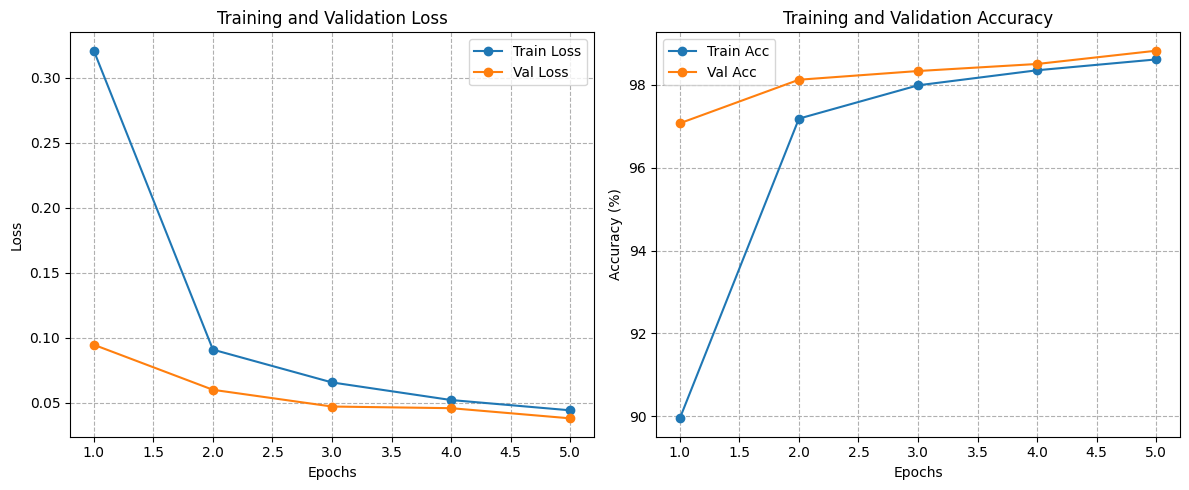

In [11]:
# ==========================================
# 4. Plotting Learning Curves (For Q1.1)
# ==========================================
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Train Acc', marker='o')
plt.plot(epochs_range, val_accs, label='Val Acc', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

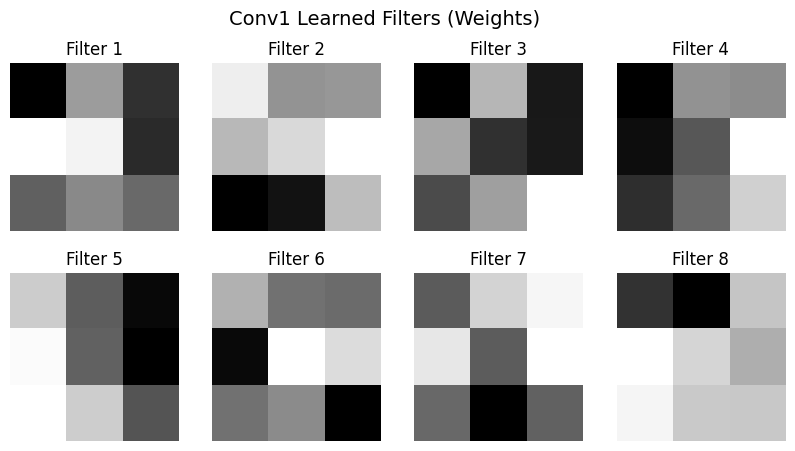

In [12]:
# ==========================================
# 5. Extract and Plot Conv1 Filters (For Q1.2)
# ==========================================
filters = model.conv1.weight.data.cpu().numpy()

plt.figure(figsize=(10, 5))
for i in range(8): # Plotting all 8 filters from conv1
    plt.subplot(2, 4, i+1)
    # The shape is [8, 1, 3, 3], we take the i-th filter and 0-th channel
    plt.imshow(filters[i, 0, :, :], cmap='gray')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.suptitle("Conv1 Learned Filters (Weights)", fontsize=14)
plt.show()

## Task 1 Part B

In [14]:
# ==========================================
# 1. Load the C-MNIST (.pt) Datasets
# ==========================================
class PTDataset(Dataset):
    def __init__(self, pt_filepath):
        data = torch.load(pt_filepath)
        if isinstance(data, tuple) or isinstance(data, list):
            self.images, self.labels = data[0], data[1]
        elif isinstance(data, dict):
            # Fallback for common dictionary keys
            self.images = data.get('images', data.get('x'))
            self.labels = data.get('labels', data.get('y'))
            
        self.images = self.images.float()
        self.labels = self.labels.long()
        
        # Ensure dimensions are [Batch, Channels, Height, Width] (3 channels for RGB)
        if self.images.ndim == 4 and self.images.shape[-1] == 3:
            self.images = self.images.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# IMPORTANT: Update these paths if your files are in a different folder!
train_loader = DataLoader(PTDataset('train_biased.pt'), batch_size=64, shuffle=True)
test_biased_loader = DataLoader(PTDataset('test_biased.pt'), batch_size=64, shuffle=False)
test_unbiased_loader = DataLoader(PTDataset('test_unbiased.pt'), batch_size=64, shuffle=False)

In [15]:
# ==========================================
# 2. Define the Part B Architecture (RGB Input)
# ==========================================
class CustomCNN_PartB(nn.Module):
    def __init__(self):
        super(CustomCNN_PartB, self).__init__()
        # THE FIX: in_channels=3 for RGB Color Images
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1) 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)                              
        
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1) 
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)                               
        
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)                               
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 3 * 3, 64) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10) 

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [16]:
# ==========================================
# 3. Training and Dual-Evaluation Loop
# ==========================================
model = CustomCNN_PartB() 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5 
train_accs_b = []
biased_accs_b = []
unbiased_accs_b = []

# Helper function to calculate accuracy for any given dataloader
def evaluate(loader, model_instance):
    correct, total = 0, 0
    model_instance.eval() # Ensure we are in eval mode before calculating
    with torch.no_grad():
        for images, labels in loader:
            outputs = model_instance(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

print("Starting Part B Training (Colored-MNIST)...")

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
    # --- Evaluation Phase ---
    # Calculate accuracies
    train_acc = evaluate(train_loader, model)
    biased_acc = evaluate(test_biased_loader, model)
    unbiased_acc = evaluate(test_unbiased_loader, model)
    
    # Store them for plotting
    train_accs_b.append(train_acc)
    biased_accs_b.append(biased_acc)
    unbiased_accs_b.append(unbiased_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | "
          f"Biased Test Acc: {biased_acc:.2f}% | Unbiased Test Acc: {unbiased_acc:.2f}%")

Starting Part B Training (Colored-MNIST)...
Epoch 1/5 | Train Acc: 96.84% | Biased Test Acc: 97.08% | Unbiased Test Acc: 59.31%
Epoch 2/5 | Train Acc: 98.40% | Biased Test Acc: 98.39% | Unbiased Test Acc: 80.05%
Epoch 3/5 | Train Acc: 98.90% | Biased Test Acc: 98.91% | Unbiased Test Acc: 82.87%
Epoch 4/5 | Train Acc: 99.01% | Biased Test Acc: 98.94% | Unbiased Test Acc: 84.32%
Epoch 5/5 | Train Acc: 99.36% | Biased Test Acc: 99.18% | Unbiased Test Acc: 88.20%


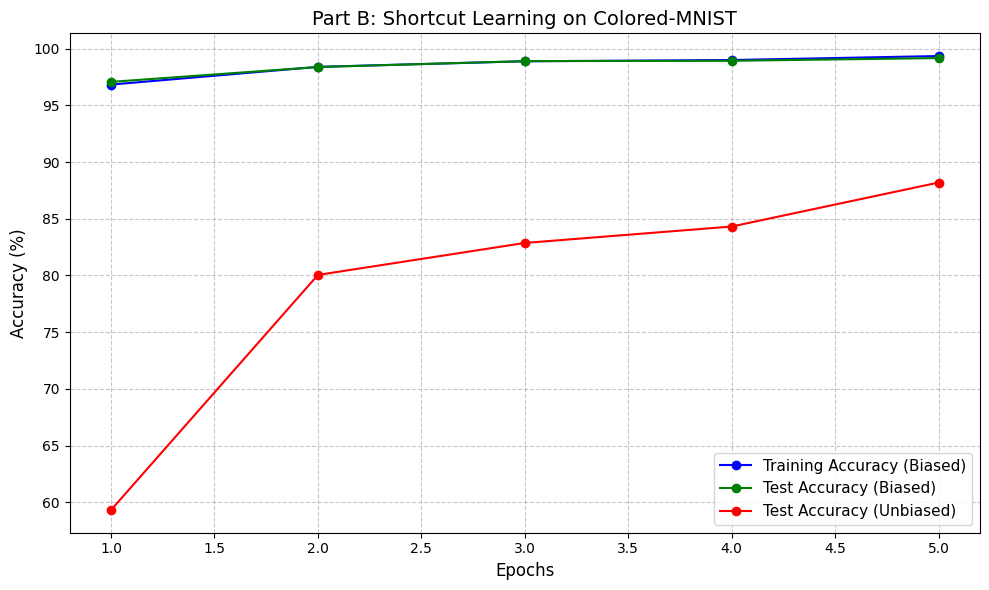

In [17]:
# ==========================================
# 4. Plotting the Shortcut Learning Phenomenon
# ==========================================
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(10, 6))

# Plot all three accuracies
plt.plot(epochs_range, train_accs_b, label='Training Accuracy (Biased)', marker='o', color='blue')
plt.plot(epochs_range, biased_accs_b, label='Test Accuracy (Biased)', marker='o', color='green')
plt.plot(epochs_range, unbiased_accs_b, label='Test Accuracy (Unbiased)', marker='o', color='red')

# Formatting
plt.title('Part B: Shortcut Learning on Colored-MNIST', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Task 2 Part A

In [18]:
# ==========================================
# Data Loading & Transforms for ResNet
# ==========================================
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Downloading STL-10 dataset...")
# STL-10 uses 'split' instead of 'train=True/False'
train_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform)
test_dataset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [19]:
# ==========================================
# 1 & 2. Load Pre-trained Model & Freeze Backbone
# ==========================================
print("Loading pre-trained ResNet-18...")
# Load the pre-trained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers in the network
for param in model.parameters():
    param.requires_grad = False

Loading pre-trained ResNet-18...


In [20]:
# ==========================================
# 3. Replace the Classification Head
# ==========================================
# Get the number of input features to the final fully connected layer
num_ftrs = model.fc.in_features

# Replace the final layer. 
# In PyTorch, newly created layers have requires_grad=True by default!
model.fc = nn.Linear(num_ftrs, 10) # 10 classes for STL-10

# Move the model to the GPU/CPU
model = model.to(device)

In [21]:
# ==========================================
# 4. Training and Evaluation
# ==========================================
criterion = nn.CrossEntropyLoss()

# VERY IMPORTANT: We only pass the parameters of the NEW classification head to the optimizer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 5 
print("\nStarting Training (Only training the final layer)...")

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # --- Evaluation Phase ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(test_loader)
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {val_loss:.4f} | Test Acc: {val_acc:.2f}%")

print(f"\nFinal Transfer Learning Accuracy on STL-10: {val_acc:.2f}%")


Starting Training (Only training the final layer)...
Epoch 1/5 | Train Loss: 0.9661 | Train Acc: 75.44% | Test Loss: 0.3897 | Test Acc: 91.61%
Epoch 2/5 | Train Loss: 0.3205 | Train Acc: 92.68% | Test Loss: 0.2673 | Test Acc: 93.17%
Epoch 3/5 | Train Loss: 0.2462 | Train Acc: 94.42% | Test Loss: 0.2191 | Test Acc: 94.22%
Epoch 4/5 | Train Loss: 0.2121 | Train Acc: 94.32% | Test Loss: 0.2012 | Test Acc: 93.91%
Epoch 5/5 | Train Loss: 0.1866 | Train Acc: 95.14% | Test Loss: 0.1846 | Test Acc: 94.24%

Final Transfer Learning Accuracy on STL-10: 94.24%


## Task 2 Part B

In [ ]:
# 1. Define the STL-10 Classes for easy labeling
stl10_classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

In [ ]:
# 2. Setup GradCAM
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

In [24]:
# 3. Find 2 Correct and 2 Incorrect Predictions
correct_samples = []
incorrect_samples = []

model.eval()
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    for i in range(len(images)):
        if preds[i] == labels[i] and len(correct_samples) < 2:
            correct_samples.append((images[i], labels[i], preds[i]))
        elif preds[i] != labels[i] and len(incorrect_samples) < 2:
            incorrect_samples.append((images[i], labels[i], preds[i]))
            
    if len(correct_samples) == 2 and len(incorrect_samples) == 2:
        break # We found our 4 images!

all_samples = correct_samples + incorrect_samples

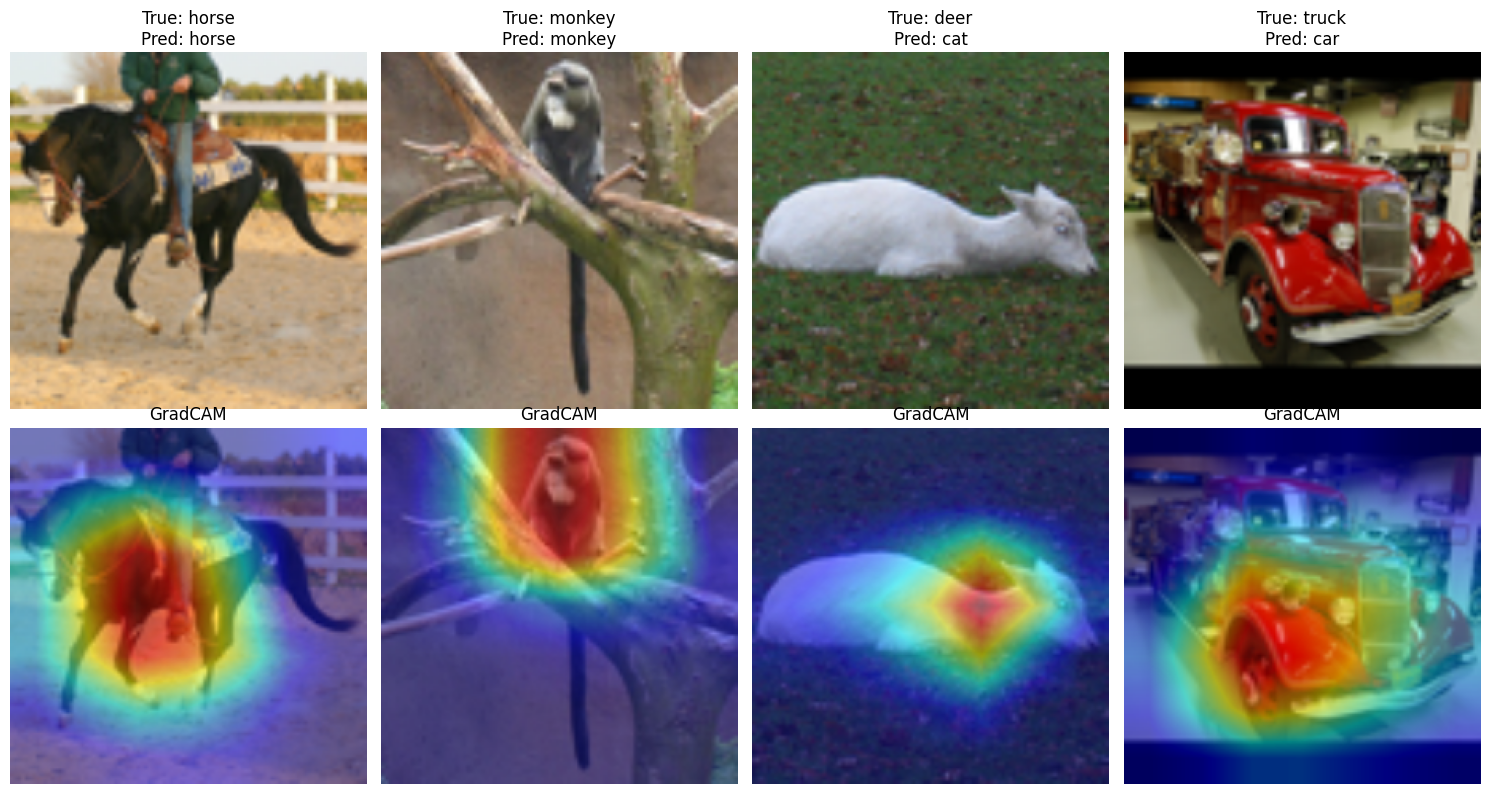

In [26]:
# 4. Generate Heatmaps and Plot
for param in model.parameters():
    param.requires_grad = True

plt.figure(figsize=(15, 8))

for i, (img_tensor, true_label, pred_label) in enumerate(all_samples):
    # Prepare the image tensor for GradCAM
    input_tensor = img_tensor.unsqueeze(0).to(device) 
    
    # We want to see where the model looked to predict the class it actually predicted
    targets = [ClassifierOutputTarget(pred_label.item())]
    
    # Generate the grayscale GradCAM heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Un-normalize the image so we can display it properly
    # ResNet normalization inverse: img = (img * std) + mean
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    unnorm_img = img_tensor * std + mean
    unnorm_img = torch.clamp(unnorm_img, 0, 1) # Ensure values are between 0 and 1
    
    # Convert tensor to numpy array in [H, W, C] format for plotting
    rgb_img = unnorm_img.cpu().permute(1, 2, 0).numpy()
    
    # Overlay the heatmap on the original image
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    # Plotting
    plt.subplot(2, 4, i + 1)
    plt.imshow(rgb_img)
    plt.title(f"True: {stl10_classes[true_label]}\nPred: {stl10_classes[pred_label]}")
    plt.axis('off')
    
    plt.subplot(2, 4, i + 5)
    plt.imshow(visualization)
    plt.title("GradCAM")
    plt.axis('off')

plt.tight_layout()
plt.show()